In [1]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt # type: ignore[import]
from matplotlib.path import Path  # type: ignore[import]
from matplotlib import colors
import pickle

import imageio
from io import BytesIO
from PIL import Image
import gc

with open('Dory_outer_control.pkl', 'rb') as f:
    outer_control = pickle.load(f)
with open('Dory_inner_control.pkl', 'rb') as f:
    inner_control = pickle.load(f)

# plt.plot(np.linspace(0,20,4001), inner_control[0:4001], color='red')
# plt.plot(np.linspace(0,20,4001), outer_control[0:4001], color='blue')
# plt.plot(np.linspace(0,20,4001), inner_control[0:4001] + outer_control[0:4001], color='black')

plt.plot(np.linspace(0,20,8001), inner_control, color='red')
plt.plot(np.linspace(0,20,8001), outer_control, color='blue')
plt.plot(np.linspace(0,20,8001), inner_control + outer_control, color='black')

FileNotFoundError: [Errno 2] No such file or directory: 'Dory_outer_control.pkl'

In [2]:
from fish import Fish
from environment import Environment

Nemo = Fish('Nemo.json')
Dory = Fish('Dory.json')
school = [Nemo, Dory]
fish_tank = Environment(school)


for fish in fish_tank.fishies:

    # Caluclate rectangular segment locations
    midpoints = (fish.positions[:,0:fish.N-1] + fish.positions[:, 1:fish.N])/2
    southwest_points = midpoints - 0.5 * fish.t * fish.l_edge_ref.T - 0.5 * fish.n * fish.h_edge_ref.T
    northwest_points = midpoints - 0.5 * fish.t * fish.l_edge_ref.T + 0.5 * fish.n * fish.h_edge_ref.T
    northeast_points = midpoints + 0.5 * fish.t * fish.l_edge_ref.T + 0.5 * fish.n * fish.h_edge_ref.T
    southeast_points = midpoints + 0.5 * fish.t * fish.l_edge_ref.T - 0.5 * fish.n * fish.h_edge_ref.T

    # Store external flow averaged around segment
    edge_boundary_velocities = np.zeros((2,fish.N-1))
    n_left_right = 20
    n_top_down = 10

    # Iterate over segments
    for ii in range(fish.N-1):

        # Discretize edges
        left_edge = np.array([
            np.linspace(southwest_points[0,ii], northwest_points[0,ii], n_top_down),
            np.linspace(southwest_points[1,ii], northwest_points[1,ii], n_top_down)
        ])
        top_edge = np.array([
            np.linspace(northwest_points[0,ii], northeast_points[0,ii], n_left_right),
            np.linspace(northwest_points[1,ii], northeast_points[1,ii], n_left_right)
        ])
        right_edge = np.array([
            np.linspace(northeast_points[0,ii], southeast_points[0,ii], n_top_down),
            np.linspace(northeast_points[1,ii], southeast_points[1,ii], n_top_down)
        ])
        bottom_edge = np.array([
            np.linspace(southeast_points[0,ii], southwest_points[0,ii], n_left_right),
            np.linspace(southeast_points[1,ii], southwest_points[1,ii], n_left_right)
        ])
        
        # Average velocity across edges
        boundary_points = np.hstack([left_edge, top_edge, right_edge, bottom_edge])
        boundary_velocities = fish_tank.fvs_flow_velocity(boundary_points) + fish_tank.external_flow_velocity(boundary_points) + fish_tank.bvs_exclude_current(boundary_points, fish)
        edge_boundary_velocities[:, ii] = np.mean(boundary_velocities, axis=1)
    
    node_boundary_velocities = (np.hstack([edge_boundary_velocities, np.zeros((2, 1))]) + np.hstack([np.zeros((2, 1)), edge_boundary_velocities])) / 2
    # fish.external_velocity = node_boundary_velocities

print(Dory.external_velocity)

[[0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]]


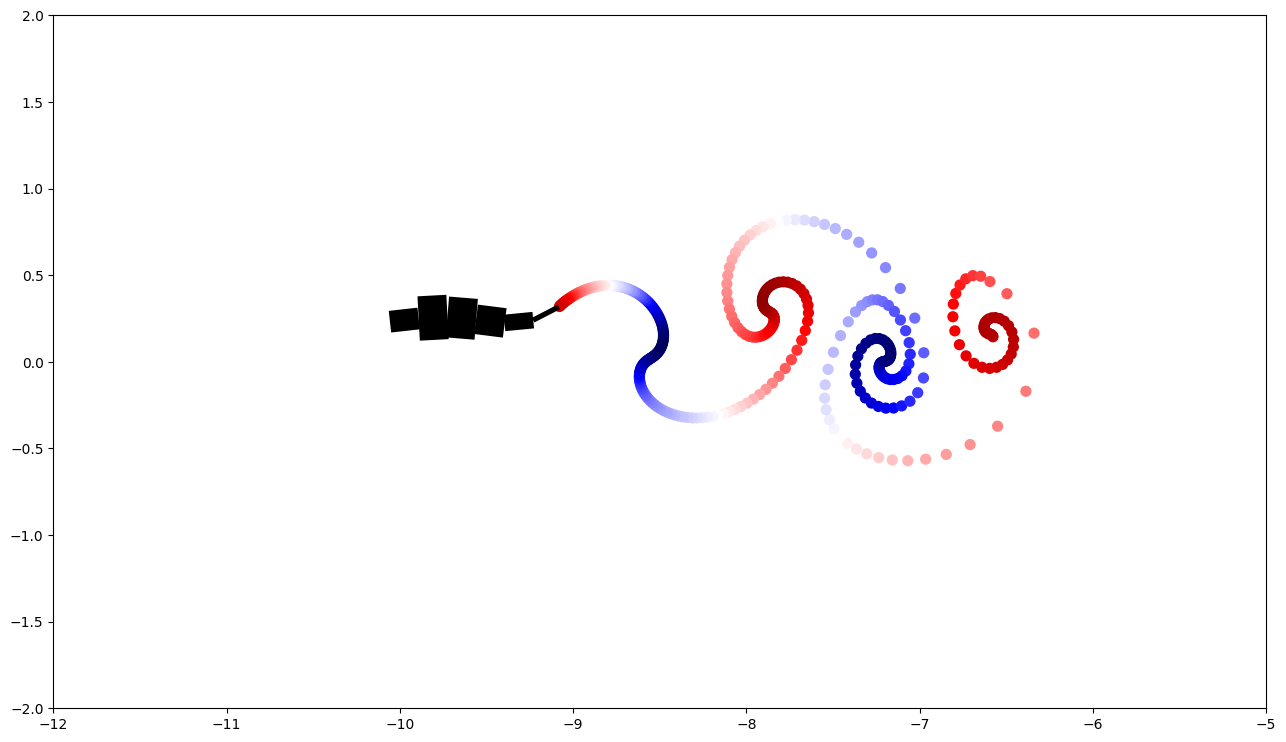

In [ ]:
from fish import Fish
from environment import Environment

Nemo = Fish('Nemo.json')
school = [Nemo]
fish_tank = Environment(school)

# Load simulation outputs
with open('robosoft_results/one_fish_OL.pkl', 'rb') as f:
    output = pickle.load(f)
with open('robosoft_results/one_fish_OL_Gamma.pkl', 'rb') as f:
    output_Gamma = pickle.load(f)
with open('robosoft_results/one_fish_OL_bvs.pkl', 'rb') as f:
    output_bvs = pickle.load(f)
with open('robosoft_results/one_fish_OL_bvs_gamma.pkl', 'rb') as f:
    output_bvs_gamma = pickle.load(f)

# Preset vortex color maps
all_Gamma = np.concatenate(output_Gamma)
if all_Gamma.size == 0:
    vmin = -1
    vmax = 1
else:
    vmin = np.min(all_Gamma)
    vmax = np.max(all_Gamma)
norm = colors.TwoSlopeNorm(vmin=vmin, vcenter=0.0, vmax=vmax)
cmap = plt.get_cmap('seismic')

# Define figure
fig, ax = plt.subplots(figsize=(16, 9))
plt.grid(True, color='gray', linestyle=':', linewidth=0.5, zorder=0)

# Choose simulation time to show
ii = 2001

# Clear image and update state at each time step
ax.clear()
current_state = output[ii]
current_Gamma = output_Gamma[ii]
bvs_index = fish_tank.fish_N * ii

# Plot each fish configuration
start = 0
for fish in fish_tank.fishies:

    end = start + 2*fish.N

    # Get node positions from ODE output
    positions = current_state[start:end].reshape((2,fish.N), order='F')

    # Calculate centerline segment positions and orientations
    midpoints = (positions[:,0:fish.N-1] + positions[:,1:fish.N])/2
    edges = positions[:,1:fish.N] - positions[:,0:fish.N-1]
    tangents = edges/np.linalg.norm(edges, axis=0)
    normals = np.vstack([-tangents[1,:], tangents[0,:]])

    # Caluclate rectangular segment locations 
    southwestPoints = midpoints - 0.5*tangents*fish.l_edge_ref.T - 0.5*normals*fish.h_edge_ref.T
    northwestPoints = midpoints - 0.5*tangents*fish.l_edge_ref.T + 0.5*normals*fish.h_edge_ref.T
    northeastPoints = midpoints + 0.5*tangents*fish.l_edge_ref.T + 0.5*normals*fish.h_edge_ref.T
    southeastPoints = midpoints + 0.5*tangents*fish.l_edge_ref.T - 0.5*normals*fish.h_edge_ref.T

    # Draw rectangular segments
    for jj in range(fish.N-1):
        rectangleX = [southwestPoints[0, jj], northwestPoints[0, jj],
                    northeastPoints[0, jj], southeastPoints[0, jj]]
        rectangleY = [southwestPoints[1, jj], northwestPoints[1, jj],
                    northeastPoints[1, jj], southeastPoints[1, jj]]
        ax.fill(rectangleX, rectangleY, 'k', zorder=2) #, label='Segments' if jj == 0 else "")

    start = end + 2*fish.N

    # # Draw true and desired headings
    # if fish_tank.control:
    #     true_direction = positions[:, 0] - positions[:, 2]
    #     quiver_true = true_direction / np.linalg.norm(true_direction)
    #     quiver_desired = fish.fish_length * fish.desired_heading_vector
    #     plt.quiver(positions[0, 0], positions[1, 0], quiver_true[0], quiver_true[1], 
    #             angles='xy', scale_units='xy', scale=1, width=0.001, headwidth=6, headlength=8, color='red')
    #     plt.quiver(positions[0, 0], positions[1, 0], quiver_desired[0], quiver_desired[1],
    #             angles='xy', scale_units='xy', scale=1, width=0.001, headwidth=6, headlength=8, color='blue')

# Plot free vortex street
vortex_data = current_state[start:]
num_vortices = vortex_data.size // 2
free_vortices = vortex_data.reshape((2,num_vortices), order='F')
sc = ax.scatter(free_vortices[0,:], free_vortices[1,:], c=current_Gamma, 
cmap=cmap, norm=norm, s=50, zorder=1)

# # Plot bound vortex sheets
# if True:
#     for fish in fish_tank.fishies:
#         current_bvs = output_bvs[bvs_index]
#         current_bvs_gamma = output_bvs_gamma[bvs_index]
#         sc_bound = ax.scatter(current_bvs[0,:], current_bvs[1,:], c=current_bvs_gamma*fish.bvs_length, 
#         cmap=cmap, norm=norm, s=10, zorder=3)
#         bvs_index += 1

# Plotting parameters
plt.xlim(-12.0,-5.0)
plt.ylim(-2.0,2.0)
ax.set_aspect('equal')
ax.grid(False)
# ax.legend()
plt.pause(0.1)


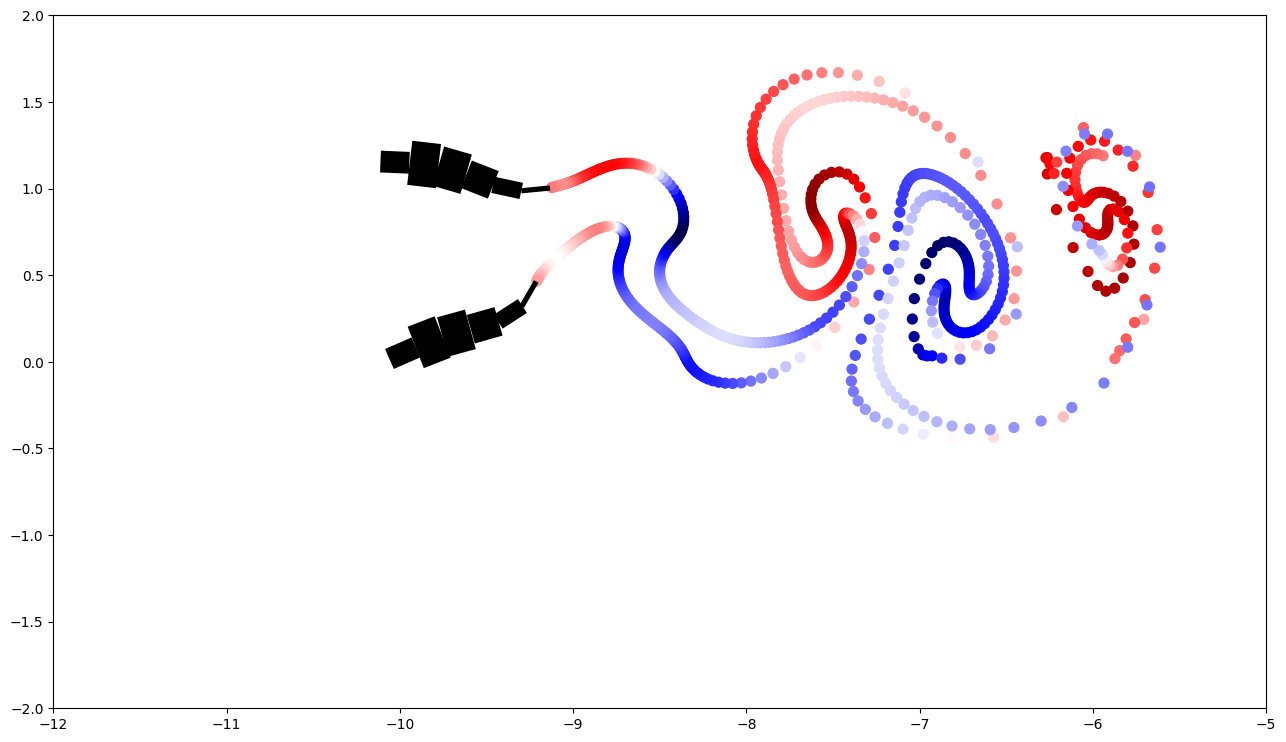

In [ ]:
from fish import Fish
from environment import Environment

Nemo = Fish('Nemo.json')
Dory = Fish('Dory.json')
school = [Nemo, Dory]
fish_tank = Environment(school)

# Load simulation outputs
with open('robosoft_results/two_fish_CL.pkl', 'rb') as f:
    output = pickle.load(f)
with open('robosoft_results/two_fish_CL_Gamma.pkl', 'rb') as f:
    output_Gamma = pickle.load(f)
with open('robosoft_results/two_fish_CL_bvs.pkl', 'rb') as f:
    output_bvs = pickle.load(f)
with open('robosoft_results/two_fish_CL_bvs_gamma.pkl', 'rb') as f:
    output_bvs_gamma = pickle.load(f)

# Preset vortex color maps
all_Gamma = np.concatenate(output_Gamma)
if all_Gamma.size == 0:
    vmin = -1
    vmax = 1
else:
    vmin = np.min(all_Gamma)
    vmax = np.max(all_Gamma)
norm = colors.TwoSlopeNorm(vmin=vmin, vcenter=0.0, vmax=vmax)
cmap = plt.get_cmap('seismic')

# Define figure
fig, ax = plt.subplots(figsize=(16, 9))
plt.grid(True, color='gray', linestyle=':', linewidth=0.5, zorder=0)

# Choose simulation time to show
ii = 4001

# Clear image and update state at each time step
ax.clear()
current_state = output[ii]
current_Gamma = output_Gamma[ii]
bvs_index = fish_tank.fish_N * ii

# Plot each fish configuration
start = 0
for fish in fish_tank.fishies:

    end = start + 2*fish.N

    # Get node positions from ODE output
    positions = current_state[start:end].reshape((2,fish.N), order='F')

    # Calculate centerline segment positions and orientations
    midpoints = (positions[:,0:fish.N-1] + positions[:,1:fish.N])/2
    edges = positions[:,1:fish.N] - positions[:,0:fish.N-1]
    tangents = edges/np.linalg.norm(edges, axis=0)
    normals = np.vstack([-tangents[1,:], tangents[0,:]])

    # Caluclate rectangular segment locations 
    southwestPoints = midpoints - 0.5*tangents*fish.l_edge_ref.T - 0.5*normals*fish.h_edge_ref.T
    northwestPoints = midpoints - 0.5*tangents*fish.l_edge_ref.T + 0.5*normals*fish.h_edge_ref.T
    northeastPoints = midpoints + 0.5*tangents*fish.l_edge_ref.T + 0.5*normals*fish.h_edge_ref.T
    southeastPoints = midpoints + 0.5*tangents*fish.l_edge_ref.T - 0.5*normals*fish.h_edge_ref.T

    # Draw rectangular segments
    for jj in range(fish.N-1):
        rectangleX = [southwestPoints[0, jj], northwestPoints[0, jj],
                    northeastPoints[0, jj], southeastPoints[0, jj]]
        rectangleY = [southwestPoints[1, jj], northwestPoints[1, jj],
                    northeastPoints[1, jj], southeastPoints[1, jj]]
        ax.fill(rectangleX, rectangleY, 'k', zorder=2) #, label='Segments' if jj == 0 else "")

    start = end + 2*fish.N

    # # Draw true and desired headings
    # if fish_tank.control:
    #     true_direction = positions[:, 0] - positions[:, 2]
    #     quiver_true = true_direction / np.linalg.norm(true_direction)
    #     quiver_desired = fish.fish_length * fish.desired_heading_vector
    #     plt.quiver(positions[0, 0], positions[1, 0], quiver_true[0], quiver_true[1], 
    #             angles='xy', scale_units='xy', scale=1, width=0.001, headwidth=6, headlength=8, color='red')
    #     plt.quiver(positions[0, 0], positions[1, 0], quiver_desired[0], quiver_desired[1],
    #             angles='xy', scale_units='xy', scale=1, width=0.001, headwidth=6, headlength=8, color='blue')

# Plot free vortex street
vortex_data = current_state[start:]
num_vortices = vortex_data.size // 2
free_vortices = vortex_data.reshape((2,num_vortices), order='F')
sc = ax.scatter(free_vortices[0,:], free_vortices[1,:], c=current_Gamma, 
cmap=cmap, norm=norm, s=50, zorder=1)

# # Plot bound vortex sheets
# if True:
#     for fish in fish_tank.fishies:
#         current_bvs = output_bvs[bvs_index]
#         current_bvs_gamma = output_bvs_gamma[bvs_index]
#         sc_bound = ax.scatter(current_bvs[0,:], current_bvs[1,:], c=current_bvs_gamma*fish.bvs_length, 
#         cmap=cmap, norm=norm, s=10, zorder=3)
#         bvs_index += 1

# Plotting parameters
# plt.xlim(-12.0,-5.0)
# plt.ylim(-2.0,2.0)
ax.set_aspect('equal')
ax.grid(False)
# ax.legend()
plt.pause(0.1)
